Here it is given a basic tutorial of SVM with scikit learn.

In [5]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

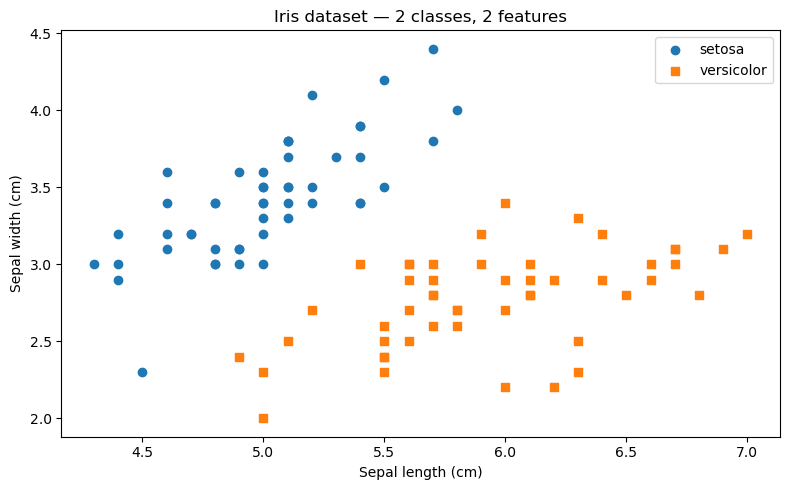

In [6]:
# --- 1. Load a toy dataset (Iris, 2 classes only) ---
iris = datasets.load_iris()
# Keep only the first two classes (setosa vs versicolor) for binary classification
mask = iris.target != 2
X = iris.data[mask][:, :2]  # use first 2 features so it's easy to visualize
y = iris.target[mask]

# Scatter plot — each colour is a class
plt.figure(figsize=(8, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="setosa", marker="o")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="versicolor", marker="s")
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Iris dataset — 2 classes, 2 features")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# --- 2. Split into train / test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
 
# --- 3. Feature scaling (important for SVM) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
 
# --- 4. Train a linear SVM ---
# C controls the soft-margin trade-off:
#   large C  → narrower margin, fewer misclassifications (less regularisation)
#   small C  → wider margin, tolerates more misclassifications (more regularisation)
clf = SVC(kernel="linear", C=1.0)
clf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [4]:
# --- 5. Evaluate ---
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["setosa", "versicolor"]))
 
# --- 6. Inspect the model ---
print("Weight vector (w):", clf.coef_)
print("Bias (b):         ", clf.intercept_)
print("Support vectors:  ", clf.n_support_)

Accuracy: 1.0

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        17
  versicolor       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Weight vector (w): [[ 1.90174734 -1.52515553]]
Bias (b):          [0.44557826]
Support vectors:   [5 5]
